In [1]:
from vmc_ising2 import (
    output_dir,
    get_config,
    get_lattice,
    default_config,
    get_network,
    get_system,
    get_eval_set,
)
from misc_utils import read_jsonl_to_df, keep_serializable, concat_columns, column_to
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from nqs_playground_helpers import safe_exp
import torch
from pathlib import Path
from collections.abc import Iterable
import jsonlines
import pandas as pd
from itertools import chain
import lattice_symmetries as ls

import scipy
import scipy.sparse
import scipy.sparse.linalg

from kagome_round import get_kagome36
from misc_utils import smooth

from datetime import datetime

time_format = "%Y_%m_%d_%H_%M_%S"

Running dilated_nns_xors.py


In [14]:
# load_tasks = ["80", "84", "85", "86", "87"]
# load_tasks = ["80", "88", "89", "92", "93", "94", "95", "96", "97", "98", "100", "101"]
# load_tasks = ["0", "1", "5", "4", "6", "7", "8"]
#load_tasks = ["0", "9", "10", "11", "12", "14", "15"]
load_tasks = ['21', '22', '23']
df = (
    read_jsonl_to_df(
        chain(*[list(output_dir.glob(f"{task}/results.jsonl")) for task in load_tasks])
        #   + list(output_dir.glob("58/results.jsonl"))
    )
    .fillna(keep_serializable(default_config))
    .fillna({"run": 0})
    .assign(
        current_timestamp=lambda df: df["current_timestamp"].apply(
            lambda x: datetime.strptime(x, time_format)
        ),
        start_timestamp=lambda df: df["start_timestamp"].apply(
            lambda x: datetime.strptime(x, time_format)
        ),
    )
    # .assign(
    #     n_signs_updated=lambda df: df.groupby("task_id")["signs_updated"].transform(
    #         "cumsum"
    #     )
    # )
)

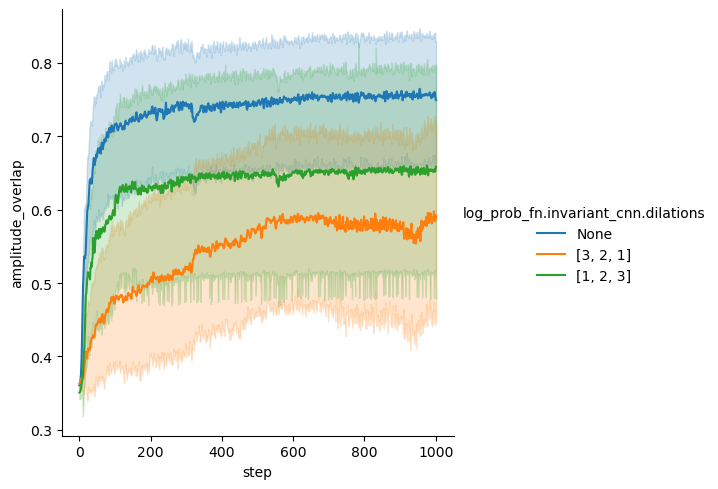

In [17]:
sns.relplot(
    df.astype({"task_id": str, "log_prob_fn.invariant_cnn.dilations": str}),
    x="step",
    y="amplitude_overlap",
    hue="log_prob_fn.invariant_cnn.dilations",
    kind="line",
#    style='run',
)

In [3]:
df.groupby("task_id")["extension_size"].mean()

KeyError: 'Column not found: extension_size'

In [4]:
df.query("not warm_up").groupby("task_id").first()['sign_overlap']

task_id
0     0.915287
9     0.402654
10    0.476594
11    0.580618
12    0.575391
14    0.961462
15    0.766246
Name: sign_overlap, dtype: float64

In [5]:
df.query('warm_up and task_id == 0 and run == 0 and step == 0').groupby('start_timestamp').size()

start_timestamp
2024-08-01 16:16:08    1
2024-08-01 16:45:28    1
2024-08-01 16:58:02    1
2024-08-01 17:14:24    1
2024-08-01 17:15:55    1
2024-08-01 17:17:28    1
2024-08-01 17:18:37    1
dtype: int64

In [6]:
df.columns

Index(['vmc.outer_sample_size', 'vmc.inner_sample_size', 'vmc.inner_epochs',
       'vmc.max_steps', 'vmc.lr', 'vmc.batch_size', 'vmc.weight_decay',
       'vmc.eval_set_max_size', 'vmc.device', 'system.lattice', 'system.J2',
       'system.symmetry_basis', 'system.spin_inversion', 'random_seed',
       'log_prob_fn', 'log_prob_fn.invariant_cnn.dilations',
       'log_prob_fn.invariant_cnn.hidden_channels',
       'log_prob_fn.invariant_cnn.kernel_size', 'warm_up',
       'warm_up.vmc_true_signs.overlap', 'warm_up.vmc_true_signs.max_steps',
       'sign_reconstruction', 'sign_reconstruction.update_each_outer_steps',
       'sign_reconstruction.annealing.number_sweeps',
       'sign_reconstruction.annealing.repetitions',
       'sign_reconstruction.extension_steps',
       'sign_reconstruction.full_spin_regularization',
       'sign_reconstruction.hadamard_spread', 'runs',
       'log_prob_fn.split_group_res_conv_net.extend_filter1',
       'log_prob_fn.split_group_res_conv_net.filter_s

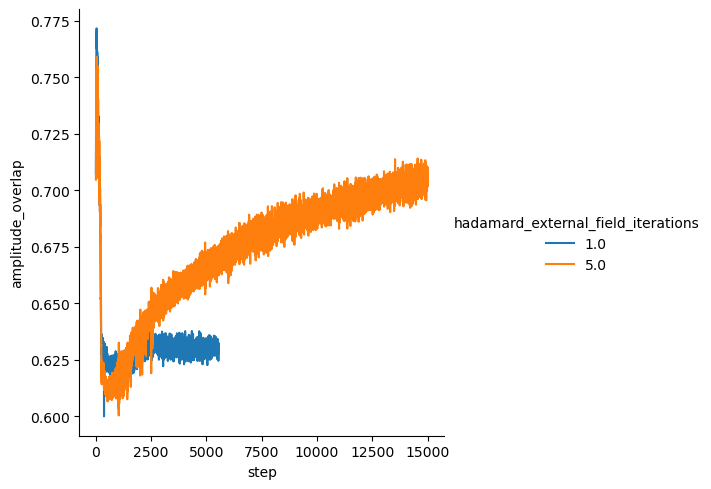

In [9]:
sns.relplot(
    df.astype(
        {
            "task_id": "category",
            "sign_reconstruction.hadamard_external_field.iterations": "category",
        }
    )
    .rename(
        columns={
            "sign_reconstruction.hadamard_external_field.iterations": "hadamard_external_field_iterations"
        }
    )
    .query("task_id in [9, 15]")
    .query("not warm_up")
    # .query("step < 100")
    # .pipe(smooth("amplitude_overlap", 100, ["start_timestamp"])).astype({"task_id": str})
    .assign(amplitude_overlap_diff=lambda x: x["amplitude_overlap"].diff())
    # .pipe(smooth("amplitude_overlap_diff", 1000, ["start_timestamp"]))
    # .pipe(smooth("sign_overlap", 100, ["start_timestamp"]))
    # .pipe(smooth("energy_delta", 100, ["start_timestamp"]))
    .assign(
        largest_over_all_component_size=lambda x: x["largest_connected_component_size"]
        / x["extension_size"]
    ),  # .query('step > 10000'),
    x="step",
    y="amplitude_overlap",
    # hue="warm_up",
    kind="line",
    hue="hadamard_external_field_iterations",
    # col_wrap=3,
)
# plt.ylim(0, 5)
# plt.ylim(0.9, 1)

In [27]:
# config = get_config(7)
# system = get_system(config)
# (lambda x: x[1] - x[0])(system.get_eigenstates(2)[0])

In [4]:
# system.get_eigenstates(2)[0]

In [5]:
df.query("not warm_up").groupby("task_id").apply(
    lambda df_group: df_group.assign(
        current_timestamp_diff=lambda x: x["current_timestamp"].diff()
    )
).reset_index(drop=True).groupby("task_id")["current_timestamp_diff"].mean()

/tmp/nix-shell.G58hEy/ipykernel_878254/3795369900.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.query('not warm_up').groupby("task_id").apply(


task_id
0   0 days 00:00:00.160500260
1   0 days 00:00:00.150392817
4   0 days 00:00:05.766944661
5   0 days 00:00:03.919281614
6   0 days 00:00:04.220835583
7   0 days 00:00:23.916514057
8   0 days 00:00:04.749744289
Name: current_timestamp_diff, dtype: timedelta64[ns]

In [34]:
(lambda x: x["extension_size"] / x["relative_extension_size"])(
    df.query("task_id == 7 and not warm_up").iloc[0]["extension_size"]
)

IndexError: invalid index to scalar variable.

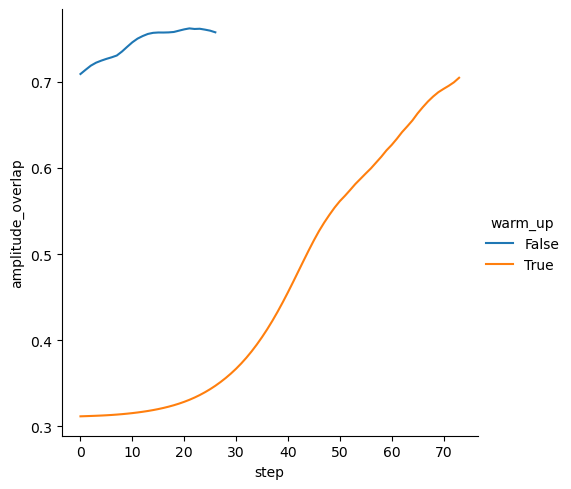

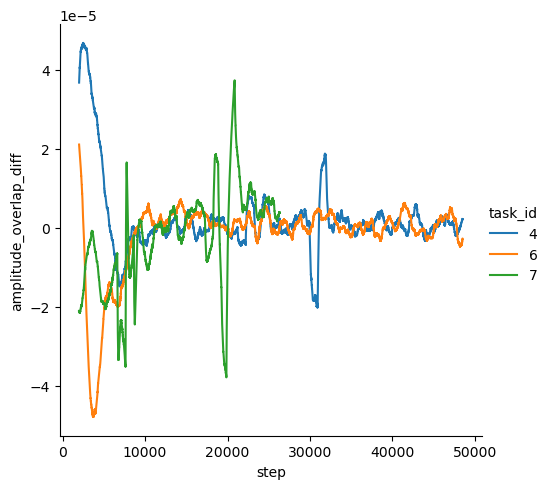

In [7]:
sns.relplot(
    df.query("task_id in [4, 6, 7] and step > 500")
    .pipe(smooth("amplitude_overlap", 1000, ["task_id"]))
    .astype({"task_id": str})
    .assign(amplitude_overlap_diff=lambda x: x["amplitude_overlap"].diff())
    .pipe(smooth("amplitude_overlap_diff", 1000, ["task_id"]))
    .pipe(smooth("sign_overlap", 1000, ["task_id"]))
    .assign(
        largest_over_all_component_size=lambda x: x["largest_connected_component_size"]
        / x["extension_size"]
    ),  # .query('step > 10000'),
    x="step",
    y="amplitude_overlap_diff",
    # hue="warm_up",
    kind="line",
    hue="task_id",
    # col_wrap=3,
)

In [ ]:
df.query("task_id == 6 and warm_up")

,vmc.outer_sample_size,vmc.inner_sample_size,vmc.inner_epochs,vmc.max_steps,vmc.lr,vmc.batch_size,vmc.weight_decay,vmc.eval_set_max_size,vmc.device,system.lattice,...,n_connected_components,largest_connected_component_size,log_prob_fn.split_group_res_conv_net.extend_filter1,log_prob_fn.split_group_res_conv_net.filter_size,log_prob_fn.split_group_res_conv_net.channels,log_prob_fn.split_group_res_conv_net.res_blocks,log_prob_fn.split_group_res_conv_net.additional_generators,log_prob_fn.invariant_res_cnn.resnet_blocks,log_prob_fn.invariant_res_cnn.resnet_block_depth,log_prob_fn.invariant_res_cnn.hidden_channels
103957,100000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,NaN,NaN,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
103958,100000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,NaN,NaN,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
103959,100000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,NaN,NaN,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
103960,100000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,NaN,NaN,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
103961,100000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,NaN,NaN,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
103962,100000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,NaN,NaN,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
103963,100000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,NaN,NaN,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
103964,100000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,NaN,NaN,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
103965,100000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,NaN,NaN,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None
103966,100000,10000,10,50000,0.001,10000,0,50000,auto,kagome36round,...,NaN,NaN,"[1, 1]","[2, 2]",16.0,4.0,"[rotation, flip]",None,None,None


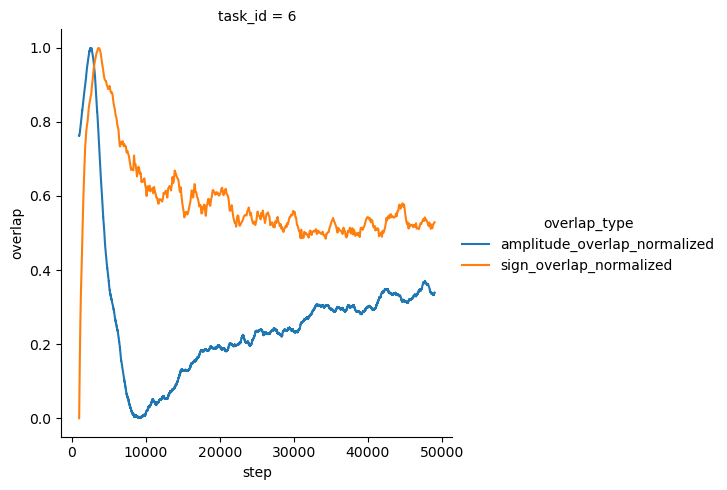

In [ ]:
sns.relplot(
    df.query("task_id == 6")
    .pipe(smooth("amplitude_overlap", 1000, ["task_id"]))
    .pipe(smooth("sign_overlap", 1000, ["task_id"]))
    .assign(
        amplitude_overlap_normalized=lambda x: (
            x["amplitude_overlap"] - x["amplitude_overlap"].min()
        )
        / (x["amplitude_overlap"].max() - x["amplitude_overlap"].min())
    )
    .assign(
        sign_overlap_normalized=lambda x: (x["sign_overlap"] - x["sign_overlap"].min())
        / (x["sign_overlap"].max() - x["sign_overlap"].min())
    )
    .melt(
        id_vars=["step", "task_id"],
        value_vars=["amplitude_overlap_normalized", "sign_overlap_normalized"],
        var_name="overlap_type",
        value_name="overlap",
    ),
    x="step",
    y="overlap",
    hue="overlap_type",
    kind="line",
    col="task_id",
)

In [ ]:
window = 100
(
    df.query("task_id == 6 and step > 500")
    .pipe(smooth("amplitude_overlap", window, ["task_id"]))
    .pipe(smooth("sign_overlap", window, ["task_id"]))
    .set_index("step")[["amplitude_overlap", "sign_overlap"]]
    .idxmax()
)

amplitude_overlap    2681
sign_overlap         3350
dtype: int64

In [8]:
window = 1000
corrs = []
for lag in range(-300, 300):
    corrs.append(
        {
            "lag": lag,
            "corr": df.query("task_id == 6 and step > 500")
            .pipe(smooth("amplitude_overlap", window, ["task_id"]))
            .pipe(smooth("sign_overlap", window, ["task_id"]))
            .assign(
                sign_overlap_delta=lambda x: x["sign_overlap"].diff(),
                amplitude_overlap_delta=lambda x: x["amplitude_overlap"].diff(),
                amplitude_overlap_delta_shift=lambda x: x[
                    "amplitude_overlap_delta"
                ].shift(lag),
                amplitude_overlap_shift=lambda x: x["amplitude_overlap"].shift(lag),
            )[["sign_overlap", "amplitude_overlap_shift"]]
            .corr()
            .iloc[0, 1],
        }
    )

KeyboardInterrupt: 

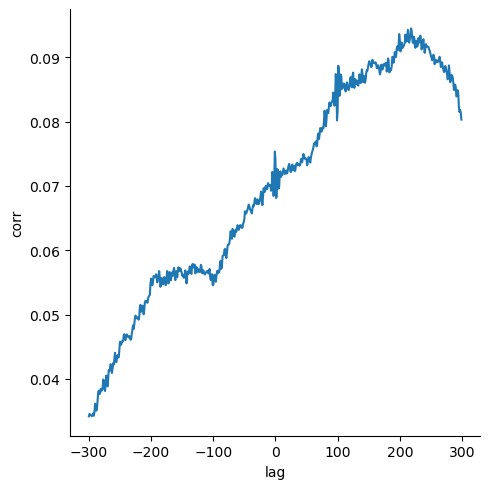

In [ ]:
sns.relplot(pd.DataFrame(corrs), x="lag", y="corr", kind="line")

In [ ]:
pd.DataFrame(dict(x=[1, 2, 3, 4], y=[10, 20, 30, 40])).assign(
    y=lambda x: x["y"].shift(-1)
)

,x,y
0,1,20.0
1,2,30.0
2,3,40.0
3,4,NaN


In [4]:
import numpy.typing as npt

In [5]:
from vmc_ising2 import (
    prepare_main,
    RunnerEnvironment,
    do_warm_up,
    connected_components,
    predict_amplitudes_numpy,
    reconstruct_signs,
)
from loguru import logger

In [11]:
def get_log_prob_network(task_id):
    (
        config,
        device,
        system,
        full_spin_matrix,
        output_dir_task,
    ) = prepare_main(task_id)
    run = 0

    runner_env = RunnerEnvironment(
        config=config,
        device=device,
        system=system,
        output_dir_task=output_dir_task,
        run=run,
        task_id=task_id,
    )

    log_prob_network = do_warm_up(
        config=config,
        device=device,
        env=runner_env,
    )
    return log_prob_network

In [12]:
def dictionary_diff(dict1, dict2):
    for key in set(dict1.keys()) | set(dict2.keys()):
        if key in dict1 and key not in dict2:
            print(f"dict1[{key}]={dict1[key]}, not in dict2")
        elif key in dict2 and key not in dict1:
            print(f"dict2[{key}]={dict2[key]}, not in dict1")
        elif dict1[key] != dict2[key]:
            print(f"dict1[{key}]={dict1[key]}, dict2[{key}]={dict2[key]}")



In [13]:
dictionary_diff(get_config(0), get_config(10))

dict1[sign_reconstruction.extension_steps]=1, dict2[sign_reconstruction.extension_steps]=2
dict1[vmc.inner_epochs]=10, dict2[vmc.inner_epochs]=1
dict1[vmc.outer_sample_size]=100000, dict2[vmc.outer_sample_size]=10000


In [53]:
log_prob_network = get_log_prob_network(10)

2024-08-01 17:24:01.852 | DEBUG    | vmc_ising2:prepare_main:418 - Torch will use device: cuda:0
2024-08-01 17:24:08.140 | DEBUG    | spin_systems:_find_cached_eigenstate:191 - Using cached version of eigenvalues / eigenstates up to 1.
2024-08-01 17:24:08.230 | DEBUG    | nqs_playground_helpers:sample_full:325 - Applying 'log_prob_fn' to all basis vectors in the Hilbert space using batch_size=10000...
2024-08-01 17:24:08.253 | DEBUG    | nqs_playground_helpers:sample_full:336 - Computing weights...
2024-08-01 17:24:08.254 | DEBUG    | nqs_playground_helpers:sample_exactly:389 - Using torch.multinomial to sample indices...
2024-08-01 17:24:08.254 | DEBUG    | nqs_playground_helpers:sample_exactly:391 - Converting probabilities to float64...
2024-08-01 17:24:08.258 | INFO     | vmc_ising2:vmc_step:480 - sign_overlap=1.0
2024-08-01 17:24:16.081 | INFO     | vmc_amplitude:compute_log_local_energies:253 - log_abs_psi_nbd.min()=0.0022731712, log_abs_psi_nbd.max()=0.014947899
2024-08-01 17:24

In [54]:
system = get_system(get_config(10))

n_states = 100_00
states = torch.from_numpy(
    np.random.choice(system.basis.states, p=system.ground_state**2, size=n_states)
)
hamiltonian = system.hamiltonian
config = get_config(10)

nbd_states: npt.NDArray[np.uint64]
matrix, nbd_states = hamiltonian.to_partial_csr(states.view(-1).cpu().numpy())  # type: ignore

extension_states = states.view(-1).cpu().numpy().sort()
extension_states_nbd: npt.NDArray[np.uint64] = nbd_states
if config["sign_reconstruction.extension_steps"] is None:
    raise ValueError("Sign reconstruction of full basis not implemented")
logger.debug(f"{states.shape=}, {nbd_states.shape=}")
for _ in range(config["sign_reconstruction.extension_steps"]):
    extension_states: npt.NDArray[np.uint64] = extension_states_nbd
    matrix, extension_states_nbd = hamiltonian.to_partial_csr(
        extension_states
    )  # type: ignore
    logger.debug(f"{extension_states.shape=}, {extension_states_nbd.shape=}")

matrix = matrix[:, np.searchsorted(extension_states_nbd, extension_states)]
assert np.abs(matrix - matrix.transpose()).max() < 1e-10

graph_matrix = (matrix != 0).astype(np.int8)
_, labels = connected_components(graph_matrix, directed=False)

relsigns = np.empty(len(extension_states), dtype=np.int8)
unique_labels = np.unique(labels)
logger.debug(f"Found {len(unique_labels)} connected components")
for component in unique_labels:
    logger.debug(f"Processing component {component}")
    component_mask = labels == component
    cluster = extension_states[component_mask]
    logger.debug(
        f"Component size: {len(cluster)} ({len(cluster) / len(hamiltonian.basis.states)} of full basis)"
    )
    matrix_block = matrix[np.ix_(component_mask, component_mask)]
    assert np.abs(matrix_block - matrix_block.transpose()).max() < 1e-10
    amplitudes = predict_amplitudes_numpy(
        log_prob_network=log_prob_network,
        states=cluster,
        batch_size=config["vmc.batch_size"],
    )
    relsigns[component_mask] = reconstruct_signs(
        predicted_amplitudes=amplitudes,
        hamiltonian_matrix=matrix_block,
        how=config["sign_reconstruction"],
        number_sweeps=config["sign_reconstruction.annealing.number_sweeps"],
        repetitions=config["sign_reconstruction.annealing.repetitions"],
    )

nbd_states_indices = np.searchsorted(extension_states, nbd_states)

2024-08-01 17:24:32.805 | DEBUG    | spin_systems:_find_cached_eigenstate:191 - Using cached version of eigenvalues / eigenstates up to 1.
2024-08-01 17:24:40.700 | DEBUG    | __main__:<module>:17 - states.shape=torch.Size([10000]), nbd_states.shape=(42554,)
2024-08-01 17:24:40.945 | DEBUG    | __main__:<module>:23 - extension_states.shape=(42554,), extension_states_nbd.shape=(114951,)
2024-08-01 17:24:41.521 | DEBUG    | __main__:<module>:23 - extension_states.shape=(114951,), extension_states_nbd.shape=(156218,)
2024-08-01 17:24:41.674 | DEBUG    | __main__:<module>:33 - Found 1 connected components
2024-08-01 17:24:41.675 | DEBUG    | __main__:<module>:35 - Processing component 0
2024-08-01 17:24:41.676 | DEBUG    | __main__:<module>:38 - Component size: 114951 (0.6760710000705766 of full basis)
2024-08-01 17:24:41.762 | DEBUG    | ising_sign_reconstruction:reconstruct_signs:21 - Creating Ising Hamiltonian matrix
2024-08-01 17:24:41.866 | DEBUG    | ising_sign_reconstruction:reconst

In [55]:
states_indices = np.searchsorted(extension_states, states.view(-1).cpu().numpy())

In [56]:
(
    relsigns[states_indices]
    * np.sign(system.get_ground_state_coeffs(states, apply_symmetries=False))
    * system.get_ground_state_coeffs(states, apply_symmetries=False) ** 2
).sum() / (
    system.get_ground_state_coeffs(states, apply_symmetries=False) ** 2
).sum()

0.41030439429564863

In [57]:
(
    relsigns[nbd_states_indices]
    * np.sign(system.get_ground_state_coeffs(nbd_states, apply_symmetries=False))
    * system.get_ground_state_coeffs(nbd_states, apply_symmetries=False) ** 2
).sum() / (
    system.get_ground_state_coeffs(nbd_states, apply_symmetries=False) ** 2
).sum()

0.5253886644866488